In [1]:
!pip install webdataset --quiet

# Experiment 02 - Deeper CNN

**Goal:** Does increasing depth increase baseline? 
**Model:** `DeepCNN`  
**Augmentation:** None (same as baseline -> isolates the effect of depth)  
**Comparison:** Macro-F1 vs Experiment 01 on the same test split

In [2]:
import sys, pathlib
ROOT = pathlib.Path('.').resolve().parent
sys.path.insert(0, str(ROOT / 'src'))

import torch.nn as nn
from config import load_config
from augmentation import build_eval_transform
from dataset import build_dataloaders
from model import DeepCNN
from training import Trainer, compute_class_weights
from utils import set_seed, show_results, load_model, evaluate_model

cfg = load_config(ROOT / 'configs/config.yaml')
set_seed(cfg.preprocessing.random_seed, cfg.device)

EXP_NAME = 'deep_cnn'
num_classes = len(cfg.classes)

eval_tf = build_eval_transform(cfg.preprocessing.image_size, use_imagenet_norm=False)

train_loader, val_loader, test_loader = build_dataloaders(
    train_transform=eval_tf,
    eval_transform=eval_tf,
    **cfg.dataloader_kwargs(),
)
print(f'Device: {cfg.device} | Dataset: {cfg.dataset_variant} | Train: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}')

[config] environment: cluster
[config] TORCH_HOME -> /home/u212917/EXP/pretrained_weights
[config] shards_dir overridden by ASL_SHARDS_DIR: /scratch/upfaabi/u212917/2915575/asl_shards_2915575
[config] device: cuda
Device: cuda | Dataset: shards | Train: 296  Val: 59  Test: 52


DeepCNN - Trainable params: 1,446,757

  Experiment: deep_cnn
  Device: cuda  |  AMP: True  |  Epochs: 50


Epoch 001/50  train_loss=2.8299  train_acc=0.1499  val_loss=2.5568  val_acc=0.2554  val_F1=0.1929  [45.8s]
  New best val macro-F1=0.1929 - checkpoint saved


Epoch 002/50  train_loss=1.7672  train_acc=0.4145  val_loss=2.0114  val_acc=0.3925  val_F1=0.3534  [40.9s]
  New best val macro-F1=0.3534 - checkpoint saved


Epoch 003/50  train_loss=1.4237  train_acc=0.5271  val_loss=1.7987  val_acc=0.4861  val_F1=0.4079  [41.4s]
  New best val macro-F1=0.4079 - checkpoint saved


Epoch 004/50  train_loss=1.2229  train_acc=0.6006  val_loss=1.9194  val_acc=0.5012  val_F1=0.4308  [40.8s]
  New best val macro-F1=0.4308 - checkpoint saved


...

Epoch 046/50  train_loss=0.0378  train_acc=0.9860  val_loss=2.0652  val_acc=0.7456  val_F1=0.6674  [40.4s]


Epoch 047/50  train_loss=0.0349  train_acc=0.9866  val_loss=2.0852  val_acc=0.7457  val_F1=0.6637  [40.3s]


Epoch 048/50  train_loss=0.0339  train_acc=0.9871  val_loss=2.0742  val_acc=0.7479  val_F1=0.6629  [40.0s]


Epoch 049/50  train_loss=0.0342  train_acc=0.9872  val_loss=2.0734  val_acc=0.7473  val_F1=0.6655  [40.0s]


Epoch 050/50  train_loss=0.0331  train_acc=0.9876  val_loss=2.0778  val_acc=0.7468  val_F1=0.6656  [40.4s]
  Early stopping triggered at epoch 50.


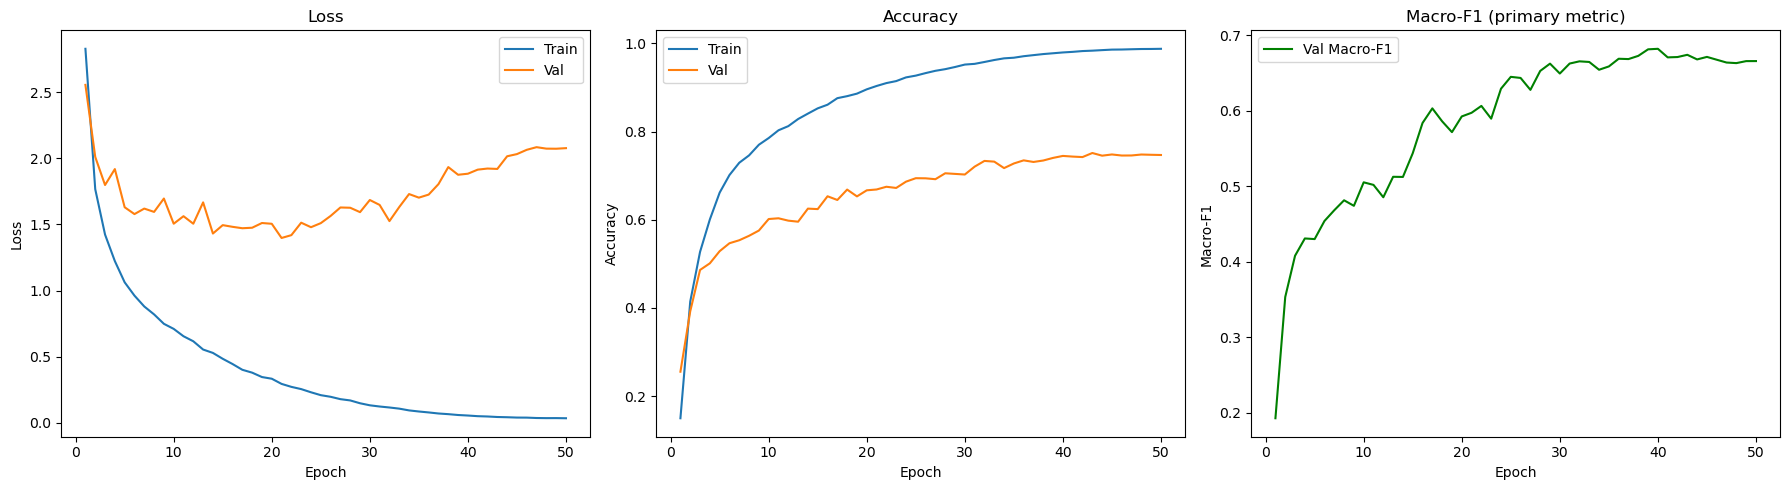

In [3]:
model = DeepCNN(in_channels=3, num_classes=num_classes)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'DeepCNN - Trainable params: {n_params:,}')

class_weights = compute_class_weights(cfg.class_weight_source, num_classes) if cfg.training.use_class_weights else None

# Set to path of last.pt to resume, or None to start fresh
RESUME_FROM = str(cfg.checkpoints_root / EXP_NAME / 'last.pt')  # e.g. str(cfg.checkpoints_root / EXP_NAME / 'last.pt')

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=cfg.device,
    exp_name=EXP_NAME,
    results_root=cfg.results_root,
    checkpoints_root=cfg.checkpoints_root,
    num_epochs=cfg.training.num_epochs,
    learning_rate=cfg.training.learning_rate,
    weight_decay=cfg.training.weight_decay,
    grad_clip=cfg.training.grad_clip,
    grad_accum_steps=cfg.training.grad_accum_steps,
    early_stopping_patience=cfg.training.early_stopping_patience,
    use_amp=cfg.training.use_amp,
    scheduler=cfg.training.scheduler,
    class_weights=class_weights,
    num_classes=num_classes,
    resume_from=RESUME_FROM,
)
history = trainer.train()

Test Macro-F1: 0.7143   Balanced Acc: 0.7711


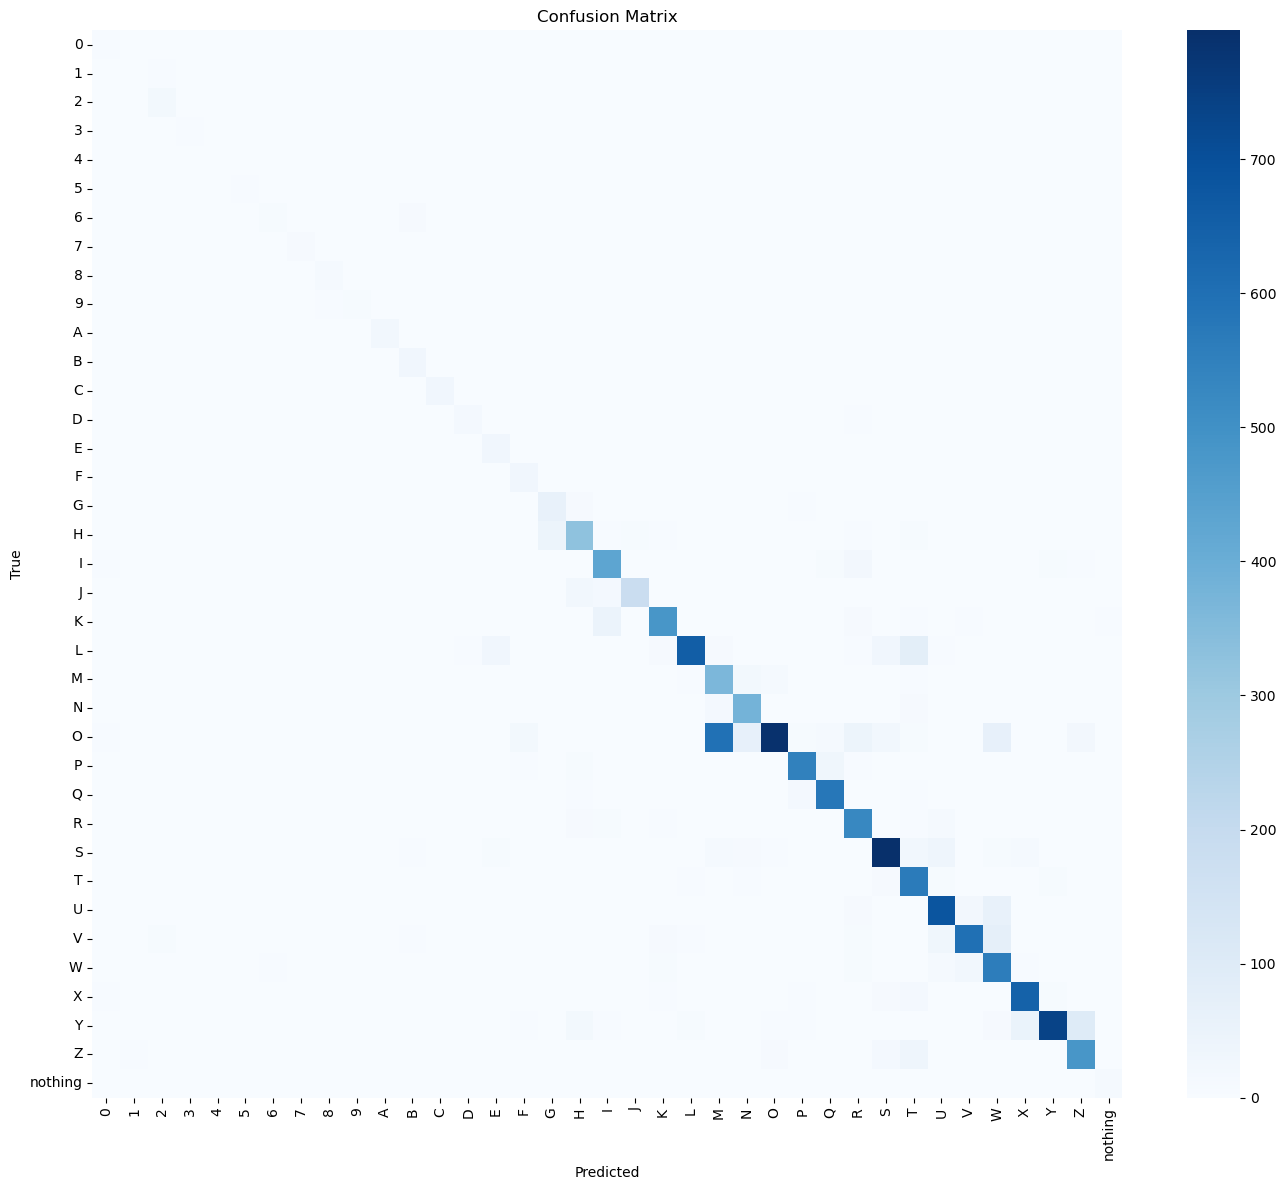

Macro-F1: 0.7143   Balanced Acc: 0.7711

Classification Report:
              precision    recall  f1-score   support

           0       0.22      0.62      0.32         8
           1       0.16      0.33      0.21         9
           2       0.49      0.87      0.62        23
           3       0.67      1.00      0.80         4
           4       1.00      0.23      0.38        13
           5       0.62      1.00      0.77         5
           6       0.39      0.47      0.43        19
           7       0.80      0.80      0.80        15
           8       0.71      0.83      0.77        18
           9       0.62      0.62      0.62        13
           A       0.81      0.64      0.71        39
           B       0.49      0.70      0.58        40
           C       0.73      0.88      0.80        34
           D       0.53      0.61      0.57        28
           E       0.38      0.78      0.51        37
           F       0.44      0.77      0.56        39
           G     

In [4]:
best_ckpt = cfg.checkpoints_root / EXP_NAME / 'best.pt'
model = load_model(DeepCNN(in_channels=3, num_classes=num_classes), str(best_ckpt), cfg.device)
_, _, test_f1, test_bal, true_labels, pred_labels = evaluate_model(
    model, test_loader, cfg.device, nn.CrossEntropyLoss()
)
print(f'Test Macro-F1: {test_f1:.4f}   Balanced Acc: {test_bal:.4f}')
show_results(true_labels, pred_labels, cfg.classes, save_dir=str(cfg.results_root / EXP_NAME))

In [5]:
import pandas as pd
hist_csv = cfg.results_root / EXP_NAME / 'history.csv'
if hist_csv.exists():
    df = pd.read_csv(hist_csv)
    display(df[['epoch', 'train_loss', 'val_loss', 'train_macro_f1', 'val_macro_f1', 'val_balanced_acc']])

,epoch,train_loss,val_loss,train_macro_f1,val_macro_f1,val_balanced_acc
0,1,2.829886,2.556766,0.126482,0.192895,0.268545
1,2,1.767183,2.011415,0.344257,0.353365,0.423610
2,3,1.423703,1.798688,0.427381,0.407934,0.514397
3,4,1.222854,1.919353,0.482939,0.430841,0.529564
4,5,1.062209,1.630450,0.537813,0.430017,0.550192
5,6,0.961381,1.578638,0.573081,0.453954,0.574546
6,7,0.879199,1.620295,0.599246,0.468188,0.592051
7,8,0.819252,1.595169,0.619391,0.481367,0.582629
8,9,0.747968,1.696380,0.643556,0.474035,0.594812
9,10,0.709597,1.505660,0.659605,0.505128,0.633478
